# Heat + Drought only: metacells2 network, EGAD, and co-expression conservation

Rebuilds the whole metacells2 pipeline on the **HD (heat + drought) cells alone**, then
runs both evaluations on the resulting network and reads them against the full-dataset
metacells2 run.

| | full run | this notebook |
| --- | --- | --- |
| cells | 30,399 (all four treatments) | 9,888 (`treatment == "HD"`) |
| construction | [`../Meta_cells_2_construction/metacells2_run.ipynb`](../Meta_cells_2_construction/metacells2_run.ipynb) | same recipe, HD cells only |
| EGAD | [`../GO_term_EGAD_evals/EGAD_eval_metacells_NCBI.ipynb`](../GO_term_EGAD_evals/EGAD_eval_metacells_NCBI.ipynb) | repeated here |
| conservation | [`../Coexpression_conservation/`](../Coexpression_conservation/) | repeated here |

Everything downstream of the cell subset is **unchanged** — same lateral gene list, same
`random_seed=476`, same divide-and-conquer defaults, same 25 % detection filter,
rank-standardised Spearman network, same NCBI `gene2go` annotation, same `MIN_COUNT` /
`MAX_COUNT` and 3-fold CV, and the same top-10 fine-to-bulk conservation score. The only
variable is which cells went in, so any difference is a consequence of dropping to one
treatment and roughly a third of the cells.

The full-run results are drawn on every figure as **dotted lines** for comparison.

> **Environment.** This notebook needs the `metacells` package, so it runs in WSL under
> the `Metacells2` kernel with `/mnt/c/...` paths — like the construction notebook, and
> unlike the EGAD notebooks, which run the Windows `Single_cell` kernel. The EGAD section
> here is the same code with WSL paths.

**A caution on reading the comparison.** Fewer cells means fewer metacells, which means
fewer samples in the correlation and a coarser detection filter, so the HD network is
expected to be noisier regardless of any biology. Treat a drop in either metric as the
combined effect of sample size and condition, not as evidence about the HD state on its own.

In [1]:
# --- metacells 0.9.5 <-> pandas 3 compatibility shims ---
# pandas 3 stores strings as ExtensionArrays (StringArray) rather than object
# ndarrays; metacells 0.9.5 assumes ndarrays in several utility functions.
# Safe to re-run: the patches are unwrapped and rebuilt from the originals.
import numpy as np
import pandas as pd
import metacells.utilities as mcu
import metacells.utilities.typing as mct


def _as_numpy(shaped):
    """pandas 3 stores strings as ExtensionArrays; metacells 0.9.5 assumes ndarrays."""
    if isinstance(shaped, (pd.DataFrame, pd.Series, pd.Index)):
        shaped = shaped.values
    if isinstance(shaped, pd.api.extensions.ExtensionArray) and not isinstance(
        shaped, pd.Categorical
    ):
        dtype = object if pd.api.types.is_string_dtype(shaped.dtype) else None
        return np.asarray(shaped, dtype=dtype)
    return None


def _convert_first(original):
    """Wrap `original` so ExtensionArray input is converted to an ndarray first."""

    def wrapper(shaped):
        converted = _as_numpy(shaped)
        return original(shaped if converted is None else converted)

    wrapper._shim_wraps = original
    return wrapper


def _skip_extension_arrays(original, result):
    """ExtensionArrays have no writeable flag: report them frozen, skip (un)freezing."""

    def wrapper(shaped):
        if _as_numpy(shaped) is not None:
            return result
        return original(shaped)

    wrapper._shim_wraps = original
    return wrapper


_SHIMS = {
    "mustbe_numpy_vector": lambda original: _convert_first(original),
    "shaped_dtype": lambda original: _convert_first(original),
    "frozen": lambda original: _skip_extension_arrays(original, True),
    "freeze": lambda original: _skip_extension_arrays(original, None),
    "unfreeze": lambda original: _skip_extension_arrays(original, None),
}

# Patch both modules: call sites use `ut.` (metacells.utilities, populated by `import *`)
# as well as `utt.` (metacells.utilities.typing), which are separate bindings to the same
# function. Unwrap anything this cell patched earlier so that re-running it re-wraps the
# ORIGINALS -- wrapping the wrappers would recurse until the stack blows.
for _name, _build_shim in _SHIMS.items():
    _original = getattr(mct, _name)
    _original = getattr(_original, "_shim_wraps", _original)
    _shim = _build_shim(_original)
    setattr(mct, _name, _shim)
    setattr(mcu, _name, _shim)
# --- end shims ---

import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import metacells as mc
import anndata as ad
import os
import scipy.sparse as sp
import shutil
from math import hypot

## Step 1 — load the cells and subset to HD

`treatment` carries the four conditions; HD is 9,888 of the 30,399 cells. The subset is
taken **before** any metacells2 call so gene selection, lateral marking, and the pile
structure are all computed on the HD cells alone.

In [2]:
import os

DATA_ROOT = "/mnt/c/Users/mikep/Data/Soybean"
PREPPED_PATH = os.path.join(
    DATA_ROOT,
    "Metacells_approaches/Pre_metacells_prepped_data",
    "prepped_data_for_metacells.h5ad",
)
HD_DIR = os.path.join(DATA_ROOT, "Metacells_approaches/Metacells2_HD")
os.makedirs(HD_DIR, exist_ok=True)

TREATMENT_COLUMN = "treatment"
TREATMENT_VALUE = "HD"
RANDOM_SEED = 476

cells = sc.read_h5ad(PREPPED_PATH)
print(f"Prepped object: {cells.n_obs:,} cells x {cells.n_vars:,} genes")
print(cells.obs[TREATMENT_COLUMN].value_counts().to_string())

cells = cells[cells.obs[TREATMENT_COLUMN] == TREATMENT_VALUE].copy()
print(
    f"\nSubset to {TREATMENT_COLUMN} == {TREATMENT_VALUE!r}: {cells.n_obs:,} cells "
    f"({cells.n_obs / 30_399:.1%} of the full run)"
)
print(cells.obs["libraries"].value_counts().to_string())

# Same var_names handling as the full run: metacells2 works on the bare locus, and
# `full_id` carries the Phytozome form the networks and annotations are keyed on.
cells.var["full_id"] = cells.var_names
cells.var_names = cells.var_names.str.replace(r"\.Wm82\.a4\.v1$", "", regex=True)
cells.var_names_make_unique()
cells

Prepped object: 30,399 cells x 29,915 genes
treatment
HD         9888
Control    9685
Heat       5505
Drought    5321

Subset to treatment == 'HD': 9,888 cells (32.5% of the full run)
libraries
leaf_HD_rep1    5498
leaf_HD_rep2    3688
leaf_HD_rep3     702


AnnData object with n_obs × n_vars = 9888 × 29915
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'pctCP', 'pctMT', 'nUMI_raw', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'treatment', 'libraries', 'replicate', 'source_rds', 'integrated_snn_res.0.5', 'celltype_call', 'cluster_annot', 'n_genes'
    var: 'highly_variable', 'in_integrated', 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'full_id'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'pca_loadings', 'source'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)

In [3]:
LATERAL_GENE_NAMES = pd.read_csv(
    os.path.join(DATA_ROOT, "Soybean_reference_info/Soybean_cell_cycle_genes.csv")
)
LATERAL_GENE_NAMES = LATERAL_GENE_NAMES["Gene ID"].to_list()

mc.pl.mark_lateral_genes(cells, lateral_gene_names=LATERAL_GENE_NAMES)
print(f"Marked {len(LATERAL_GENE_NAMES)} lateral (cell cycle) genes")

set unnamed.var[lateral_gene]: 70 true (0.234%) out of 29915 bools


Marked 129 lateral (cell cycle) genes


In [4]:
max_parallel_piles = mc.pl.guess_max_parallel_piles(cells)
print(f"guess_max_parallel_piles: {max_parallel_piles}")
# mc.pl.set_max_parallel_piles(max_parallel_piles)

guess_max_parallel_piles: 20


In [5]:
with mc.ut.progress_bar():
    mc.pl.divide_and_conquer_pipeline(cells, random_seed=RANDOM_SEED)

Detect rare gene modules...
  0%|          [00:00]/home/mikep/Linux_conda/envs/Metacells2/lib/python3.14/site-packages/metacells/utilities/computation.py:1563: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  result = np.reciprocal(mean_per_element, where=~zeros_mask)
100%|██████████[00:30]


In [6]:
FIT_PATH = os.path.join(HD_DIR, "metacells2_HD_object_output.h5ad")
META_PATH = os.path.join(HD_DIR, "metacells2_HD_metacell_summarized_output.h5ad")

# `total_umis` holds the summed UMIs per gene per metacell; `X` is gene *fractions*, so
# the network below is built from the layer, not from X.
metacells = mc.pl.collect_metacells(
    cells, name="metacells2_HD.metacells", random_seed=RANDOM_SEED
)

grouped = metacells.obs["grouped"]
print(
    f"{cells.n_obs:,} HD cells -> {metacells.n_obs} metacells "
    f"({int(metacells.uns['outliers']):,} outlier cells left unassigned)"
)
print(
    f"  cells per metacell: min={grouped.min()}, median={grouped.median():.0f}, "
    f"max={grouped.max()}, mean={grouped.mean():.1f}"
)
print("\nFull run, for reference: 30,399 cells -> 505 metacells")

cells.write_h5ad(FIT_PATH)
metacells.write_h5ad(META_PATH)
print(f"\nWrote:\n  {FIT_PATH}\n  {META_PATH}")

set metacells2_HD.metacells.obs[grouped]: 174 int64s
set metacells2_HD.metacells.obs[total_umis]: 174 int64s
set metacells2_HD.metacells.layers[total_umis]: ndarray 174 X 29915 float32s
set metacells2_HD.metacells.obs[__zeros_downsample_umis]: 174 int64s
set metacells2_HD.metacells.layers[zeros]: ndarray 174 X 29915 int32s
set unnamed.obs[metacell_name]: 9888 <U8s
set metacells2_HD.metacells.var[highly_variable]: 2502 true (8.364%) out of 29915 bools
set metacells2_HD.metacells.var[in_integrated]: 2965 true (9.911%) out of 29915 bools
set metacells2_HD.metacells.var[n_cells]: 29915 int64s
set metacells2_HD.metacells.var[means]: 29915 float64s
set metacells2_HD.metacells.var[dispersions]: 29915 float64s
set metacells2_HD.metacells.var[dispersions_norm]: 29915 float32s
set metacells2_HD.metacells.var[full_id]: 29915 objects
set metacells2_HD.metacells.var[lateral_gene]: 70 true (0.234%) out of 29915 bools
set metacells2_HD.metacells.var[selected_gene]: 260 true (0.8691%) out of 29915 boo

9,888 HD cells -> 174 metacells (11 outlier cells left unassigned)
  cells per metacell: min=29, median=56, max=95, mean=56.8

Full run, for reference: 30,399 cells -> 505 metacells

Wrote:
  /mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2_HD/metacells2_HD_object_output.h5ad
  /mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2_HD/metacells2_HD_metacell_summarized_output.h5ad


## Step 2 — build the HD co-expression network

Identical to the full run's network cell: CPM per metacell, Spearman by the rank trick,
then rank standardised and divided by the maximum rank (CoCoCoNet), with genes kept only
if detected in >= 25 % of metacells. Because there are far fewer HD metacells than the
505 of the full run, that 25 % is a much smaller absolute number of metacells, and fewer
samples go into every correlation.

In [7]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scipy.stats as sci
import h5py

RANDOM_SEED = 476
np.random.seed(RANDOM_SEED)  # pipeline below is deterministic; set for consistency

MIN_METACELL_FRACTION = 0.25  # keep genes detected in >= 25% of metacells
RANK_CHUNK_ROWS = 500  # rows per chunk when rank standardising the network

# ---------------------------------------------------------------- read objects
# Re-read from disk rather than relying on the in-memory object so this cell can be
# re-run on a fresh kernel without repeating the divide-and-conquer fit.
metacells = sc.read_h5ad(META_PATH)
grouped = np.asarray(metacells.obs["grouped"], dtype=float)
print(
    f"Summarized object: {metacells.n_obs} metacells x {metacells.n_vars:,} genes "
    f"({int(metacells.uns['outliers']):,} outlier cells excluded by metacells2)"
)
print(
    f"  cells per metacell: min={grouped.min():.0f}, median={np.median(grouped):.0f}, "
    f"max={grouped.max():.0f}, mean={grouped.mean():.1f}"
)

NETWORK_PATH = os.path.join(
    HD_DIR, f"metacells2_HD_{metacells.n_obs}_metacell_coexpression_network.h5"
)

# Metacell-summed counts (metacells x genes).
counts = metacells.layers["total_umis"]
counts = counts.toarray() if sp.issparse(counts) else np.asarray(counts)
counts = counts.astype(np.float64)

# Label genes with their full Phytozome IDs -- cell 1 stripped the ".Wm82.a4.v1" suffix
# from var_names, but the SEACells network and the downstream conservation notebook both
# key on the full form.
gene_names = np.asarray(
    metacells.var["full_id"] if "full_id" in metacells.var else metacells.var_names,
    dtype=object,
)
n_metacells = counts.shape[0]

# ---------------------------------------------------------------- gene filter
min_metacells = int(np.ceil(MIN_METACELL_FRACTION * n_metacells))
detected_in = (counts > 0).sum(axis=0)
keep = detected_in >= min_metacells
print(
    f"\nGene filter: keeping genes detected in >= {MIN_METACELL_FRACTION:.0%} of "
    f"metacells ({min_metacells}/{n_metacells})"
)
print(
    f"  {int(keep.sum()):,} of {keep.size:,} genes kept "
    f"({int((~keep).sum()):,} dropped)"
)
counts = counts[:, keep]
gene_names = gene_names[keep]

# --------------------------------------------- CPM normalisation per metacell
# CoCoCoNet is silent on library-size normalisation, and metacells2 targets a fixed UMI
# budget per metacell (target_metacell_umis=160,000) so sizes are more uniform here than
# in the SEACells run -- but Spearman ranks each gene *across* metacells, so any residual
# size spread would still tilt the ranks. Normalised anyway, identically to the SEACells
# network, so the two are built the same way.
lib_sizes = counts.sum(axis=1)
print(
    f"\nMetacell library sizes: min={lib_sizes.min():,.0f}, "
    f"median={np.median(lib_sizes):,.0f}, max={lib_sizes.max():,.0f} "
    f"({lib_sizes.max() / lib_sizes.min():.1f}x spread)"
)
expr = (counts / lib_sizes[:, None]) * 1e6
del counts

# ------------------------------------------------------- Spearman correlation
# Same rank trick as build_coexpression_networks.py: rank each gene across samples,
# centre, scale to unit length, then the dot product of the rows is Spearman's rho.
expr = expr.T  # genes x metacells, matching the template's row-wise ranking
print(f"\nRanking {expr.shape[0]:,} genes across {expr.shape[1]} metacells ...")
ranks = sci.rankdata(expr, method="average", axis=1)
del expr

# Average ranks always sum to n(n+1)/2, so every gene's mean rank is (n+1)/2 even
# with ties (metacell data has plenty of tied zeros).
ranks -= (n_metacells + 1) / 2.0
norms = np.sqrt(np.square(ranks).sum(axis=1))

# A zero norm means a constant rank vector (no variance) -> correlation undefined.
# CoCoCoNet fills such NAs with the network median, but that only makes sense when
# aggregating over datasets; with a single dataset the gene carries no information,
# so drop it instead.
variable = norms > 0
if not variable.all():
    print(f"  dropping {int((~variable).sum()):,} zero-variance genes")
    ranks = ranks[variable]
    norms = norms[variable]
    gene_names = gene_names[variable]

ranks = (ranks / norms[:, None]).astype(np.float32)
del norms

n_genes = ranks.shape[0]
print(
    f"Computing {n_genes:,} x {n_genes:,} Spearman correlations "
    f"(~{n_genes ** 2 * 4 / 1e9:.2f} GB, float32) ..."
)
network = ranks @ ranks.T
del ranks

# Defensive: with zero-variance genes removed there should be no NAs left, but if any
# survive, fill them with the median network value the way CoCoCoNet does.
n_nan = int(np.isnan(network).sum())
if n_nan:
    median_value = np.nanmedian(network)
    print(
        f"  filling {n_nan:,} NA correlations with the network median "
        f"({median_value:.4f})"
    )
    np.nan_to_num(network, copy=False, nan=median_value)
np.clip(network, -1.0, 1.0, out=network)  # tidy up float error at the extremes

# --------------------------------------------------- CoCoCoNet standardisation
# "rank standardized and normalized by dividing through by the maximum rank".
# Done with a sorted copy plus chunked searchsorted so peak memory stays at roughly
# two copies of the matrix rather than the ~4 copies np.argsort would need.
print("Rank standardising the adjacency matrix ...")
flat = network.reshape(-1)
sorted_values = np.sort(flat)
n_edges = sorted_values.size
# Maximum average rank: ties at the top share the mean of their positions.
top_left = int(np.searchsorted(sorted_values, sorted_values[-1], side="left"))
max_rank = (top_left + n_edges + 1) / 2.0

for start in range(0, n_genes, RANK_CHUNK_ROWS):
    stop = min(start + RANK_CHUNK_ROWS, n_genes)
    block = network[start:stop].reshape(-1)
    lo = np.searchsorted(sorted_values, block, side="left")
    hi = np.searchsorted(sorted_values, block, side="right")
    network[start:stop] = (((lo + hi + 1) / 2.0) / max_rank).reshape(
        stop - start, n_genes
    )
del sorted_values

np.fill_diagonal(network, 1.0)  # keep self-edges at the top of the scale
print(
    f"  edge weights now span {network.min():.6f} to {network.max():.6f} "
    f"(median {np.median(network):.4f})"
)

# ------------------------------------------------------------------- save out
# Same on-disk layout as the SEACells network: the matrix and its gene labels as two
# plain datasets (h5py rather than DataFrame.to_hdf, which would need pytables and an
# extra in-memory copy). Read it back with the loader defined below.
with h5py.File(NETWORK_PATH, "w") as handle:
    handle.create_dataset("network", data=network, dtype="float32")
    handle.create_dataset(
        "genes", data=gene_names.astype(object), dtype=h5py.string_dtype()
    )
    handle["network"].attrs["metric"] = "spearman"
    handle["network"].attrs["postprocessing"] = "rank standardized / max rank"
    handle["network"].attrs["normalization"] = "CPM per metacell"
    handle["network"].attrs["min_metacell_fraction"] = MIN_METACELL_FRACTION
    handle["network"].attrs["n_metacells"] = n_metacells
    handle["network"].attrs["grouping"] = str(
        metacells.uns.get("metacells_algorithm", "metacells")
    )

print(
    f"\nSaved {n_genes:,} x {n_genes:,} network "
    f"({os.path.getsize(NETWORK_PATH) / 1e9:.2f} GB) to:\n  {NETWORK_PATH}"
)


def load_coexpression_network(path=NETWORK_PATH, genes=None):
    """Read the saved network back. Pass `genes` to pull only those rows/columns,
    which avoids loading the full matrix when you only want a few genes."""
    with h5py.File(path, "r") as handle:
        all_genes = handle["genes"].asstr()[:]
        if genes is None:
            values = handle["network"][:]
            labels = all_genes
        else:
            lookup = {gene: i for i, gene in enumerate(all_genes)}
            missing = [g for g in genes if g not in lookup]
            if missing:
                raise KeyError(f"not in the network: {missing}")
            idx = np.sort([lookup[g] for g in genes])
            values = handle["network"][idx][:, idx]
            labels = all_genes[idx]
    return pd.DataFrame(values, index=labels, columns=labels)


# Preview the top-left corner without materialising a second copy of the matrix.
pd.DataFrame(network[:5, :5], index=gene_names[:5], columns=gene_names[:5])

Summarized object: 174 metacells x 29,915 genes (11 outlier cells excluded by metacells2)
  cells per metacell: min=29, median=56, max=95, mean=56.8

Gene filter: keeping genes detected in >= 25% of metacells (44/174)
  21,603 of 29,915 genes kept (8,312 dropped)

Metacell library sizes: min=77,018, median=116,680, max=193,958 (2.5x spread)

Ranking 21,603 genes across 174 metacells ...
Computing 21,603 x 21,603 Spearman correlations (~1.87 GB, float32) ...
Rank standardising the adjacency matrix ...
  edge weights now span 0.000000 to 1.000000 (median 0.5000)

Saved 21,603 x 21,603 network (1.87 GB) to:
  /mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2_HD/metacells2_HD_174_metacell_coexpression_network.h5


,Glyma.01G161700.Wm82.a4.v1,Glyma.03G158766.Wm82.a4.v1,Glyma.03G058100.Wm82.a4.v1,Glyma.09G060300.Wm82.a4.v1,Glyma.09G210700.Wm82.a4.v1
Glyma.01G161700.Wm82.a4.v1,1.000000,0.938038,0.932327,0.969055,0.239435
Glyma.03G158766.Wm82.a4.v1,0.938038,1.000000,0.810685,0.906453,0.350008
Glyma.03G058100.Wm82.a4.v1,0.932327,0.810685,1.000000,0.839832,0.871408
Glyma.09G060300.Wm82.a4.v1,0.969055,0.906453,0.839832,1.000000,0.385429
Glyma.09G210700.Wm82.a4.v1,0.239435,0.350008,0.871408,0.385429,1.000000


# Part 2 — EGAD

GO term modularity in the HD network, scored by EGAD neighbour voting on NCBI `gene2go`
annotations. Same procedure and same parameters as
[`../GO_term_EGAD_evals/EGAD_eval_metacells_NCBI.ipynb`](../GO_term_EGAD_evals/EGAD_eval_metacells_NCBI.ipynb),
so the AUROCs are directly comparable to the full run's.

In [8]:
import numpy as np
import pandas as pd
from scipy import stats, sparse
import bottleneck


def run_egad(go, nw, **kwargs):
    """EGAD running function

    Wrapper to lower level functions for EGAD

    EGAD measures modularity of gene lists in co-expression networks.

    This was translated from the MATLAB version, which does tiled Cross Validation

    Two lines carry `# pandas 3` / `nan_policy` fixes for modern pandas and scipy; both
    are marked with a comment and neither changes the arithmetic.

    The useful kwargs are:
    int - nFold : Number of CV folds to do, default is 3,
    int - {min,max}_count : limits for number of terms in each gene list, these are exclusive values


    Arguments:
        go {pd.DataFrame} -- dataframe of genes x terms of values [0,1], where 1 is included in gene lists
        nw {pd.DataFrame} -- dataframe of co-expression network, genes x genes
        **kwargs

    Returns:
        pd.DataFrame -- dataframe of terms x metrics where the metrics are
        ['AUC', 'AVG_NODE_DEGREE', 'DEGREE_NULL_AUC', 'P_Value']
    """
    assert nw.shape[0] == nw.shape[1], "Network is not square"
    assert np.all(
        nw.index == nw.columns
    ), "Network index and columns are not in the same order"
    nw_mask = (nw.isna().sum(axis=1) != nw.shape[1]).to_numpy()
    kept = nw.index[nw_mask]
    # pandas 3 copy-on-write hands back read-only arrays from `.values`, so the diagonal
    # goes onto an explicit writable copy rather than in place. Before pandas 3 this was
    # `nw = nw.loc[nw_mask, nw_mask].astype(float)` / `np.fill_diagonal(nw.values, 1)`.
    values = nw.loc[kept, kept].to_numpy(dtype=float, copy=True)
    np.fill_diagonal(values, 1)
    nw = pd.DataFrame(values, index=kept, columns=kept)
    return _runNV(go, nw, **kwargs)


def _runNV(go, nw, nFold=3, min_count=20, max_count=1000):

    # Make sure genes are same in go and nw
    genes_intersect = go.index.intersection(nw.index)

    go = go.loc[genes_intersect, :]
    nw = nw.loc[genes_intersect, genes_intersect]

    # Make sure there aren't duplicates
    duplicates = nw.index.duplicated(keep="first")
    nw = nw.loc[~duplicates, ~duplicates]

    go = go.loc[:, (go.sum(axis=0) > min_count) & (go.sum(axis=0) < max_count)]
    go = go.loc[~go.index.duplicated(keep="first"), :]

    roc = _new_egad(go.values, nw.values, nFold)

    col_names = ["AUC", "AVG_NODE_DEGREE", "DEGREE_NULL_AUC", "P_Value"]
    # Put output in dataframe
    return pd.DataFrame(dict(zip(col_names, roc)), index=go.columns)


def _new_egad(go, nw, nFold):

    # Build Cross validated Positive
    x, y = np.where(go)
    cvgo = {}
    for i in np.arange(nFold):
        a = x[i::nFold]
        b = y[i::nFold]
        dat = np.ones_like(a)
        mask = sparse.coo_matrix((dat, (a, b)), shape=go.shape)
        cvgo[i] = go - mask.toarray()

    CVgo = np.concatenate(list(cvgo.values()), axis=1)

    sumin = np.matmul(nw.T, CVgo)

    degree = np.sum(nw, axis=0)

    predicts = sumin / degree[:, None]

    np.place(predicts, CVgo > 0, np.nan)

    # Calculate ranks of positives.
    # `nan_policy="omit"` is scipy >= 1.10's name for the behaviour this was written
    # against: rank the real values 1..n and leave the NaNs -- the held-in positives,
    # masked back out on the next line -- out of it. Since 1.10 the default is
    # "propagate", which returns an *all-NaN* array instead, so every rank sum comes out
    # 0 and every AUC collapses to the constant -(n_p + 1) / (2 * n_n). No exception is
    # raised, so leaving this off looks like a network with no structure in it.
    rank_abs = lambda x: stats.rankdata(np.abs(x), nan_policy="omit")
    predicts2 = np.apply_along_axis(rank_abs, 0, predicts)

    # Masking Nans that were ranked (how tiedrank works in matlab)
    predicts2[np.isnan(predicts)] = np.nan

    filtering = np.tile(go, nFold)

    # negatives :filtering == 0
    # Sets Ranks of negatives to 0
    np.place(predicts2, filtering == 0, 0)

    # Sum of ranks for each prediction
    p = bottleneck.nansum(predicts2, axis=0)

    # Number of predictions
    # Number of 1's masked for each GO term for each CV
    n_p = np.sum(filtering, axis=0) - np.sum(CVgo, axis=0)

    # Number of negatives
    # Number of GO terms - number of postiive
    n_n = filtering.shape[0] - np.sum(filtering, axis=0)

    roc = (p / n_p - (n_p + 1) / 2) / n_n
    U = roc * n_p * n_n
    Z = (np.abs(U - (n_p * n_n / 2))) / np.sqrt(n_p * n_n * (n_p + n_n + 1) / 12)
    roc = roc.reshape(nFold, go.shape[1])
    Z = Z.reshape(nFold, go.shape[1])
    # Stouffer Z method
    Z = bottleneck.nansum(Z, axis=0) / np.sqrt(nFold)
    # Calc ROC of Neighbor Voting
    roc = bottleneck.nanmean(roc, axis=0)
    P = stats.norm.sf(Z)

    # Average degree for nodes in each go term
    avg_degree = degree.dot(go) / np.sum(go, axis=0)

    # Calc null auc for degree
    ranks = np.tile(stats.rankdata(degree), (go.shape[1], 1)).T

    np.place(ranks, go == 0, 0)

    n_p = bottleneck.nansum(go, axis=0)
    nn = go.shape[0] - n_p
    p = bottleneck.nansum(ranks, axis=0)

    roc_null = (p / n_p - ((n_p + 1) / 2)) / nn

    return roc, avg_degree, roc_null, P

## Step 3 — annotation and configuration

`gene2go.txt` is ~11 GB, so it is streamed, filtered to taxid 3847, and cached. The cache
and the `gene_info` subset were both written by the earlier notebooks; this only re-reads
them.

In [9]:
import glob
import urllib.request

np.random.seed(RANDOM_SEED)  # EGAD's CV folds are deterministic; set for consistency

NCBI_DIR = "/mnt/c/Users/mikep/Data/NCBI"
REFERENCE_DIR = os.path.join(DATA_ROOT, "Soybean_reference_info")

GENE2GO_ALL = os.path.join(NCBI_DIR, "gene2go.txt")
GENE2GO_SOY = os.path.join(NCBI_DIR, "Glycine_max_3847.gene2go.csv")
GENE_INFO_SOY = os.path.join(NCBI_DIR, "Glycine_max_3847.gene_info.csv")
OBO_PATH = os.path.join(REFERENCE_DIR, "go-basic.obo")

# The metacell count is only known once the fit has run, so resolve the filename.
_networks = sorted(
    glob.glob(os.path.join(HD_DIR, "metacells2_HD_*_metacell_coexpression_network.h5"))
)
assert len(_networks) == 1, f"expected one HD network in {HD_DIR}, found {_networks}"
NETWORK_PATH = _networks[0]
N_HD_METACELLS = int(os.path.basename(NETWORK_PATH).split("_")[2])
NETWORK_LABEL = f"metacells2 HD ({N_HD_METACELLS} metacells)"
print(f"HD network: {NETWORK_PATH}")

RESULTS_PATH = "metacells2_HD_GO_egad_results_ncbi.csv"
PROPAGATED_RESULTS_PATH = "metacells2_HD_GO_egad_results_ncbi_propagated.csv"

# The full-dataset metacells2 run on the same annotation -- the dotted lines below.
FULL_RESULTS_PATH = "../GO_term_EGAD_evals/metacells2_GO_egad_results_ncbi.csv"
FULL_PROPAGATED_PATH = (
    "../GO_term_EGAD_evals/metacells2_GO_egad_results_ncbi_propagated.csv"
)
FULL_LABEL = "metacells2, all 30,399 cells (505 metacells)"

GLYCINE_MAX_TAXID = 3847
KEEP_CATEGORIES = ("Process", "Component")  # gene2go's names for BP and CC
CATEGORY_TO_NAMESPACE = {
    "Process": "biological_process",
    "Component": "cellular_component",
    "Function": "molecular_function",
}
N_FOLD = 3
MIN_COUNT, MAX_COUNT = 10, 500  # exclusive bounds on term size
READ_CHUNK_ROWS = 500  # rows per slab when pulling the network off disk

if os.path.exists(GENE2GO_SOY):
    gene2go = pd.read_csv(GENE2GO_SOY, dtype=str)
    print(f"Loaded cached Glycine max gene2go: {len(gene2go):,} rows")
else:
    print(f"Streaming {GENE2GO_ALL} and filtering to taxid {GLYCINE_MAX_TAXID} ...")
    kept = []
    for chunk in pd.read_csv(
        GENE2GO_ALL, sep="\t", dtype=str, chunksize=1_000_000, low_memory=False
    ):
        chunk = chunk.rename(columns={"#tax_id": "tax_id"})
        kept.append(chunk[chunk["tax_id"] == str(GLYCINE_MAX_TAXID)])
    gene2go = pd.concat(kept, ignore_index=True)
    gene2go.to_csv(GENE2GO_SOY, index=False)
    print(f"Cached {len(gene2go):,} Glycine max rows to {GENE2GO_SOY}")

print(
    f"\n{gene2go['GeneID'].nunique():,} genes, {gene2go['GO_ID'].nunique():,} GO terms"
)
print(gene2go["Category"].value_counts().to_string())
print(f"\nEvidence codes: {gene2go['Evidence'].value_counts().to_dict()}")
gene2go.head()

HD network: /mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2_HD/metacells2_HD_174_metacell_coexpression_network.h5
Loaded cached Glycine max gene2go: 110,380 rows

35,092 genes, 3,946 GO terms
Category
Function     48564
Process      35099
Component    26717

Evidence codes: {'IEA': 110380}


,tax_id,GeneID,GO_ID,Evidence,Qualifier,GO_term,PubMed,Category
0,3847,547449,GO:0004568,IEA,enables,chitinase activity,30032202,Function
1,3847,547449,GO:0005576,IEA,located_in,extracellular region,30032202,Component
2,3847,547449,GO:0005975,IEA,involved_in,carbohydrate metabolic process,22301074,Process
3,3847,547450,GO:0046872,IEA,enables,metal ion binding,30032202,Function
4,3847,547451,GO:0006952,IEA,involved_in,defense response,22301074,Process


## Step 2 - map NCBI `GeneID`s onto the network's gene names

`gene_info`'s `LocusTag` is the bridge. The conversion runs network-side (`Glyma...` ->
`GLYMA_...v4`) rather than the other way, because 18,328 of the 59,141 `gene_info` rows carry
no `LocusTag` at all (`-`) and would need dropping either way, and because a handful of the
real ones are organellar or unanchored (`GlmaCp081`, `GLYMA_U031413v4`) and simply will not
match a nuclear gene model.

In [10]:
gene_info = pd.read_csv(GENE_INFO_SOY, dtype=str)
print(f"gene_info: {len(gene_info):,} rows")

has_locus_tag = gene_info["LocusTag"] != "-"
print(f"  {int((~has_locus_tag).sum()):,} rows have no LocusTag and are dropped")
locus_to_geneid = (
    gene_info[has_locus_tag].drop_duplicates("LocusTag").set_index("LocusTag")["GeneID"]
)
print(f"  LocusTag -> GeneID entries: {len(locus_to_geneid):,}")


def glyma_to_locustag(gene):
    """Glyma.01G161700.Wm82.a4.v1 -> GLYMA_01G161700v4 (the NCBI LocusTag form)."""
    core = gene.split(".Wm82")[0]  # Glyma.01G161700
    return "GLYMA_" + core.split(".", 1)[1] + "v4"


with h5py.File(NETWORK_PATH, "r") as handle:
    network_genes = handle["genes"].asstr()[:]
network_position = pd.Series(np.arange(len(network_genes)), index=network_genes)
print(f"\nNetwork: {len(network_genes):,} genes, e.g. {network_genes[0]}")

gene_to_geneid = pd.Series(
    [glyma_to_locustag(gene) for gene in network_genes], index=network_genes
).map(locus_to_geneid)
mapped = gene_to_geneid.dropna()
print(
    f"  {len(mapped):,} map to an NCBI GeneID "
    f"({len(mapped) / len(network_genes):.1%}); {int(gene_to_geneid.isna().sum()):,} do not"
)
assert not mapped.duplicated().any(), "two network genes share a GeneID"

gene_info: 59,141 rows
  18,328 rows have no LocusTag and are dropped
  LocusTag -> GeneID entries: 40,813

Network: 21,603 genes, e.g. Glyma.01G161700.Wm82.a4.v1
  19,999 map to an NCBI GeneID (92.6%); 1,604 do not


## Step 3 - keep Process and Component

`gene2go` records the ontology itself, in `Category`, so unlike the Phytozome file this does
not need `go-basic.obo` to decide what is what. The obo is still parsed - for term names on
obsolete entries, for `alt_id` remapping, and for the `is_a` / `part_of` edges the propagation
step needs.

`NOT` qualifiers (an explicit statement that a gene does *not* do something) would have to be
excluded; soybean happens to have none, but the filter is applied rather than assumed.

In [11]:
if not os.path.exists(OBO_PATH):
    # geneontology.org rejects the default urllib agent with a 403.
    print(f"Downloading go-basic.obo to {OBO_PATH} ...")
    request = urllib.request.Request(
        "https://current.geneontology.org/ontology/go-basic.obo",
        headers={"User-Agent": "Mozilla/5.0"},
    )
    with urllib.request.urlopen(request, timeout=120) as response, open(
        OBO_PATH, "wb"
    ) as handle:
        handle.write(response.read())


def parse_obo(path):
    """Pull per-term metadata and the parent edges of the GO DAG out of an OBO file.

    Returns id -> name, id -> namespace, alt_id -> id, the set of obsolete ids, and
    id -> {parent ids}. The parents come from `is_a` and `part_of`, the two relations GO
    annotations propagate over; they are unused until step 6.
    """
    names, namespaces, alt_ids, obsolete, parents = {}, {}, {}, set(), {}
    part_of = "relationship: part_of "
    term_id, in_term = None, False
    with open(path) as handle:
        for line in handle:
            line = line.rstrip("\n")
            if line.startswith("["):  # [Term], [Typedef], ...
                in_term, term_id = line == "[Term]", None
            elif in_term:
                if line.startswith("id: "):
                    term_id = line[4:]
                    parents.setdefault(term_id, set())
                elif line.startswith("name: "):
                    names[term_id] = line[6:]
                elif line.startswith("namespace: "):
                    namespaces[term_id] = line[11:]
                elif line.startswith("alt_id: "):
                    alt_ids[line[8:]] = term_id
                elif line == "is_obsolete: true":
                    obsolete.add(term_id)
                elif line.startswith("is_a: "):  # "is_a: GO:0009521 ! photosystem"
                    parents[term_id].add(line[6:].split(" ! ")[0])
                elif line.startswith(part_of):
                    parents[term_id].add(line[len(part_of) :].split(" ! ")[0])
    return names, namespaces, alt_ids, obsolete, parents


go_name, go_namespace, go_alt_id, go_obsolete, go_parents = parse_obo(OBO_PATH)
print(
    f"go-basic.obo: {len(go_namespace):,} terms, {len(go_alt_id):,} alt_ids, "
    f"{len(go_obsolete):,} obsolete, "
    f"{sum(len(p) for p in go_parents.values()):,} is_a / part_of edges"
)

go-basic.obo: 48,340 terms, 3,646 alt_ids, 10,248 obsolete, 63,726 is_a / part_of edges


In [12]:
annotations = gene2go[gene2go["Category"].isin(KEEP_CATEGORIES)].copy()
print(
    f"Process + Component: {len(annotations):,} rows "
    f"({len(gene2go) - len(annotations):,} Function rows dropped)"
)

negated = annotations["Qualifier"].fillna("").str.contains("NOT")
print(f"  NOT-qualified annotations excluded: {int(negated.sum()):,}")
annotations = annotations[~negated]

# Attach the network gene name, and remap GO IDs that have been merged into another term.
geneid_to_gene = pd.Series(mapped.index, index=mapped.to_numpy())
annotations["gene"] = annotations["GeneID"].map(geneid_to_gene)
annotations = annotations.dropna(subset=["gene"])
annotations["GO"] = annotations["GO_ID"].map(lambda term: go_alt_id.get(term, term))
annotations["namespace"] = annotations["Category"].map(CATEGORY_TO_NAMESPACE)

# gene2go's own GO_term text is kept where the obo has nothing (obsolete or retired ids).
go_term_text = annotations.drop_duplicates("GO").set_index("GO")["GO_term"].to_dict()
term_name = {term: go_name.get(term, go_term_text.get(term)) for term in go_term_text}

gene_go = annotations[["gene", "GO", "namespace"]].drop_duplicates(ignore_index=True)
print(
    f"\n{len(gene_go):,} gene-GO pairs over {gene_go['gene'].nunique():,} network genes "
    f"and {gene_go['GO'].nunique():,} terms"
)
print(gene_go["namespace"].value_counts().to_string())

# Sanity check: Category and the obo should agree wherever the obo knows the term.
from_obo = gene_go["GO"].map(go_namespace)
disagree = from_obo.notna() & (from_obo != gene_go["namespace"])
print(f"\nCategory vs go-basic.obo disagreements: {int(disagree.sum()):,}")
print(f"terms the obo does not list at all: {int(from_obo.isna().sum()):,}")

Process + Component: 61,816 rows (48,564 Function rows dropped)
  NOT-qualified annotations excluded: 0

32,921 gene-GO pairs over 13,820 network genes and 2,161 terms
namespace
biological_process    17475
cellular_component    15446

Category vs go-basic.obo disagreements: 0
terms the obo does not list at all: 0


## Step 4 - build the gene x term matrix and read the network

As before, the network is restricted to genes carrying at least one Process/Component term -
`_runNV` intersects the two anyway, so this is identical arithmetic on a much smaller matrix.

In [13]:
def read_network_subset(path, dataset, index, chunk_rows=READ_CHUNK_ROWS):
    """Read a symmetric gene x gene subset without materialising the full matrix.

    Same helper as the conservation notebook: `index` may be in any order, but h5py needs
    strictly increasing row indices, so rows are fetched sorted and written straight to
    their destination slots.
    """
    order = np.argsort(index)
    sorted_index = index[order]
    size = len(index)
    out = np.empty((size, size), dtype=np.float32)
    with h5py.File(path, "r") as handle:
        dset = handle[dataset]
        for start in range(0, size, chunk_rows):
            stop = min(start + chunk_rows, size)
            block = dset[sorted_index[start:stop], :]
            out[order[start:stop]] = block[:, index]
    return out

In [14]:
shared_genes = np.sort(gene_go["gene"].unique())
n_shared = len(shared_genes)
N_EGAD_GENES = n_shared  # the conservation section below rebinds n_shared
print(
    f"{n_shared:,} of {len(network_genes):,} network genes carry a Process/Component "
    f"term ({n_shared / len(network_genes):.1%})"
)

go_matrix = (
    pd.crosstab(gene_go["gene"], gene_go["GO"]).reindex(index=shared_genes).fillna(0)
)
go_matrix = (go_matrix > 0).astype(float)
term_sizes = go_matrix.sum(axis=0)
print(f"GO matrix: {go_matrix.shape[0]:,} genes x {go_matrix.shape[1]:,} terms")
print(
    f"  {int(((term_sizes > MIN_COUNT) & (term_sizes < MAX_COUNT)).sum())} terms have "
    f"{MIN_COUNT} < size < {MAX_COUNT} and will be scored"
)

print(
    f"\nReading network subset ({n_shared:,} x {n_shared:,}, "
    f"~{n_shared ** 2 * 4 / 1e9:.2f} GB) ..."
)
network = pd.DataFrame(
    read_network_subset(
        NETWORK_PATH, "network", network_position.loc[shared_genes].to_numpy()
    ),
    index=shared_genes,
    columns=shared_genes,
)
print(
    f"  edges span {np.nanmin(network.values):.4f} to {np.nanmax(network.values):.4f}, "
    f"{int(np.isnan(network.values).sum()):,} NaN"
)

13,820 of 21,603 network genes carry a Process/Component term (64.0%)
GO matrix: 13,820 genes x 2,161 terms
  523 terms have 10 < size < 500 and will be scored

Reading network subset (13,820 x 13,820, ~0.76 GB) ...
  edges span 0.0000 to 1.0000, 0 NaN


## Step 5 - run EGAD

In [15]:
def annotate(frame, matrix):
    """Attach term size, ontology, and name to a run_egad result."""
    frame = frame.copy()
    frame["n_genes"] = matrix.loc[:, frame.index].sum(axis=0).astype(int)
    frame["namespace"] = frame.index.map(go_namespace)
    frame["term_name"] = frame.index.map(term_name)
    frame["is_obsolete"] = frame.index.isin(go_obsolete)
    frame.index.name = "GO"
    return frame.sort_values("AUC", ascending=False)


def summarise(frame, label):
    print(f"{label}: {len(frame)} GO terms")
    print(
        f"  AUROC: mean {frame['AUC'].mean():.3f}, median {frame['AUC'].median():.3f}, "
        f"range {frame['AUC'].min():.3f}-{frame['AUC'].max():.3f}"
    )
    print(
        f"  {int((frame['AUC'] > 0.5).sum())} terms above chance, "
        f"{int((frame['P_Value'] < 0.05).sum())} with P < 0.05"
    )
    print(f"  degree-only null AUROC: mean {frame['DEGREE_NULL_AUC'].mean():.3f}\n")
    print(frame.groupby("namespace")["AUC"].agg(["count", "mean", "median"]).round(3))


results = annotate(
    run_egad(
        go_matrix, network, nFold=N_FOLD, min_count=MIN_COUNT, max_count=MAX_COUNT
    ),
    go_matrix,
)
summarise(results, "Direct NCBI annotations")

results.to_csv(RESULTS_PATH)
print(f"\nSaved to {RESULTS_PATH}")
results.head(15)[
    ["AUC", "P_Value", "DEGREE_NULL_AUC", "n_genes", "namespace", "term_name"]
]

/tmp/ipykernel_2074/735124238.py:122: RuntimeWarning: invalid value encountered in divide
  roc = (p / n_p - (n_p + 1) / 2) / n_n


Direct NCBI annotations: 523 GO terms
  AUROC: mean 0.660, median 0.660, range 0.280-0.986
  473 terms above chance, 384 with P < 0.05
  degree-only null AUROC: mean 0.498

                    count   mean  median
namespace                               
biological_process    350  0.665   0.665
cellular_component    173  0.651   0.640

Saved to metacells2_HD_GO_egad_results_ncbi.csv


,AUC,P_Value,DEGREE_NULL_AUC,n_genes,namespace,term_name
GO,,,,,,
GO:0042542,0.986192,6.784969e-26,0.014516,39,biological_process,response to hydrogen peroxide
GO:0051259,0.985964,7.857672e-24,0.010034,36,biological_process,protein complex oligomerization
GO:0009538,0.957136,1.371579e-08,0.075235,13,cellular_component,photosystem I reaction center
GO:0009522,0.952156,1.204543e-10,0.088393,18,cellular_component,photosystem I
GO:0010287,0.935283,4.587940e-09,0.142639,15,cellular_component,plastoglobule
GO:0009651,0.932526,3.798279e-21,0.069646,39,biological_process,response to salt stress
GO:0009768,0.929396,4.775205e-15,0.175772,28,biological_process,"photosynthesis, light harvesting in photosystem I"
GO:0030388,0.928613,2.377648e-09,0.139194,16,biological_process,"fructose 1,6-bisphosphate metabolic process"
GO:0015979,0.923718,1.715799e-34,0.143054,69,biological_process,photosynthesis


## Step 6 - propagate up the GO DAG and re-run

Identical to step 6 of the Phytozome notebook: GO's true path rule says an annotation to a
term is also an annotation to all of that term's ancestors, and `gene2go` records only the
most specific term.

In [16]:
import sys

sys.setrecursionlimit(10_000)
_ancestor_cache = {}


def ancestors(term):
    """Every term reachable from `term` by is_a / part_of, memoised over the whole DAG."""
    if term in _ancestor_cache:
        return _ancestor_cache[term]
    _ancestor_cache[term] = frozenset()  # guard against a cycle re-entering this term
    found = set()
    for parent in go_parents.get(term, ()):
        found.add(parent)
        found |= ancestors(parent)
    _ancestor_cache[term] = frozenset(found)
    return _ancestor_cache[term]


# `gene_go` is already restricted to BP/CC and to genes in the network. Propagating it
# rather than the full annotation is only safe if no term's ancestors sit in another
# ontology, which go-basic guarantees -- checked rather than assumed.
crossing = [
    (term, ancestor)
    for term, namespace in gene_go[["GO", "namespace"]]
    .drop_duplicates()
    .itertuples(index=False)
    for ancestor in ancestors(term)
    if go_namespace.get(ancestor) != namespace
]
assert (
    not crossing
), f"{len(crossing)} ancestor edges cross ontologies, e.g. {crossing[:3]}"

In [17]:
propagated = pd.DataFrame(
    [
        (gene, ancestor)
        for gene, term in gene_go[["gene", "GO"]].itertuples(index=False)
        for ancestor in (term, *ancestors(term))
    ],
    columns=["gene", "GO"],
).drop_duplicates(ignore_index=True)
propagated["namespace"] = propagated["GO"].map(go_namespace)

print(
    f"direct:     {len(gene_go):,} pairs, {gene_go['GO'].nunique():,} terms\n"
    f"propagated: {len(propagated):,} pairs, {propagated['GO'].nunique():,} terms "
    f"({len(propagated) / len(gene_go):.1f}x)"
)

propagated_genes = np.sort(propagated["gene"].unique())
assert np.array_equal(
    propagated_genes, shared_genes
), "gene set moved; re-read the network"

go_matrix_propagated = (
    pd.crosstab(propagated["gene"], propagated["GO"])
    .reindex(index=shared_genes)
    .fillna(0)
)
go_matrix_propagated = (go_matrix_propagated > 0).astype(float)
propagated_sizes = go_matrix_propagated.sum(axis=0)
print(
    f"  {int(((propagated_sizes > MIN_COUNT) & (propagated_sizes < MAX_COUNT)).sum())} "
    f"terms scoreable, up from {len(results)}"
)

# The propagated matrix is ~7x the direct one and EGAD makes several float64 copies of
# the network, so drop the direct run's matrix first. See the memory note in step 3.
import gc

del go_matrix
gc.collect()

results_propagated = annotate(
    run_egad(
        go_matrix_propagated,
        network,
        nFold=N_FOLD,
        min_count=MIN_COUNT,
        max_count=MAX_COUNT,
    ),
    go_matrix_propagated,
)
summarise(results_propagated, "\nPropagated NCBI annotations")

results_propagated.to_csv(PROPAGATED_RESULTS_PATH)
print(f"\nSaved to {PROPAGATED_RESULTS_PATH}")
results_propagated.head(15)[
    ["AUC", "P_Value", "DEGREE_NULL_AUC", "n_genes", "namespace", "term_name"]
]

direct:     32,921 pairs, 2,161 terms
propagated: 315,098 pairs, 3,806 terms (9.6x)
  1511 terms scoreable, up from 523


/tmp/ipykernel_2074/735124238.py:122: RuntimeWarning: invalid value encountered in divide
  roc = (p / n_p - (n_p + 1) / 2) / n_n



Propagated NCBI annotations: 1511 GO terms
  AUROC: mean 0.638, median 0.635, range 0.241-0.986
  1377 terms above chance, 1126 with P < 0.05
  degree-only null AUROC: mean 0.508

                    count   mean  median
namespace                               
biological_process   1190  0.636   0.634
cellular_component    321  0.644   0.642

Saved to metacells2_HD_GO_egad_results_ncbi_propagated.csv


,AUC,P_Value,DEGREE_NULL_AUC,n_genes,namespace,term_name
GO,,,,,,
GO:0042542,0.985975,3.906027e-26,0.014516,39,biological_process,response to hydrogen peroxide
GO:0051259,0.968850,1.891762e-23,0.031525,38,biological_process,protein complex oligomerization
GO:0009538,0.954922,9.908614e-09,0.075235,13,cellular_component,photosystem I reaction center
GO:0009522,0.951296,1.672197e-12,0.086062,20,cellular_component,photosystem I
GO:0010287,0.936583,2.504767e-09,0.142639,15,cellular_component,plastoglobule
GO:0000302,0.930473,1.225986e-30,0.084765,61,biological_process,response to reactive oxygen species
GO:0009521,0.930046,2.344452e-32,0.138694,63,cellular_component,NaN
GO:0009768,0.922401,4.721288e-15,0.175772,28,biological_process,"photosynthesis, light harvesting in photosystem I"
GO:0031428,0.922020,1.267112e-06,0.682533,12,cellular_component,box C/D methylation guide snoRNP complex


## Step 6 — the AUROC distributions, against the full run

The HD network scores fewer terms than the full run (fewer metacells means a harsher
detection filter, so fewer genes carry an annotation and fewer terms clear `min_count`).
Raw counts would therefore make the two look different for reasons that have nothing to do
with modularity, so the y axis is the **proportion of terms scored** rather than a count.

The full run is drawn as a dotted step outline with a dotted median line; the HD run is
the filled bars with a solid median line.

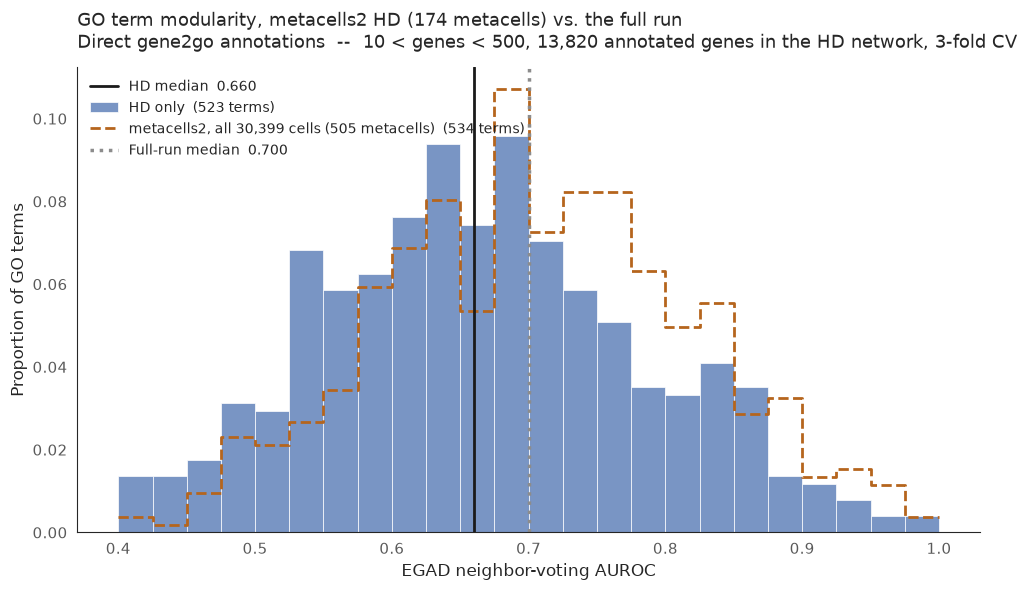

Direct gene2go annotations
  HD        median 0.660, 523 terms
  full run  median 0.700, 534 terms
  difference -0.040


In [30]:
full_results = pd.read_csv(FULL_RESULTS_PATH, index_col="GO")
full_results_propagated = pd.read_csv(FULL_PROPAGATED_PATH, index_col="GO")


def plot_auroc_histogram(frame, full_frame, subtitle):
    """HD AUROC distribution as bars, the full run as a dotted outline behind it.

    Both are drawn as proportions so the two term counts do not distort the comparison.
    """
    median = float(frame["AUC"].median())
    full_median = float(full_frame["AUC"].median())
    bins, binrange = 24, (0.4, 1.0)

    sns.set_style("white")
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.histplot(
        frame["AUC"],
        bins=bins,
        binrange=binrange,
        stat="proportion",
        color="#4C72B0",
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
        label=f"HD only  ({len(frame)} terms)",
    )
    sns.histplot(
        full_frame["AUC"],
        bins=bins,
        binrange=binrange,
        stat="proportion",
        element="step",
        fill=False,
        color="#B5651D",
        linewidth=2,
        linestyle="--",
        ax=ax,
        label=f"{FULL_LABEL}  ({len(full_frame)} terms)",
    )

    ax.axvline(
        median,
        color="#1A1A1A",
        linestyle="-",
        linewidth=2,
        label=f"HD median  {median:.3f}",
    )
    ax.axvline(
        full_median,
        color="#8C8C8C",
        linestyle=":",
        linewidth=2.5,
        label=f"Full-run median  {full_median:.3f}",
    )

    ax.set_xlabel("EGAD neighbor-voting AUROC", fontsize=12)
    ax.set_ylabel("Proportion of GO terms", fontsize=12)
    ax.set_title(
        f"GO term modularity, {NETWORK_LABEL} vs. the full run\n"
        f"{subtitle}  --  {MIN_COUNT} < genes < {MAX_COUNT}, "
        f"{N_EGAD_GENES:,} annotated genes in the HD network, {N_FOLD}-fold CV",
        fontsize=13,
        loc="left",
        pad=14,
    )
    # seaborn appends the bar patch last; lead with the HD series, which is the subject.
    _handles, _labels = ax.get_legend_handles_labels()
    _order = sorted(range(len(_labels)), key=lambda i: not _labels[i].startswith("HD"))
    ax.legend(
        [_handles[i] for i in _order],
        [_labels[i] for i in _order],
        loc="upper left",
        frameon=False,
        fontsize=10,
    )
    ax.grid(False)
    sns.despine(ax=ax)
    ax.tick_params(labelsize=11, colors="#5A5A5A")
    fig.tight_layout()
    plt.show()

    print(f"{subtitle}\n  HD        median {median:.3f}, {len(frame)} terms")
    print(f"  full run  median {full_median:.3f}, {len(full_frame)} terms")
    print(f"  difference {median - full_median:+.3f}")


plot_auroc_histogram(results, full_results, "Direct gene2go annotations")

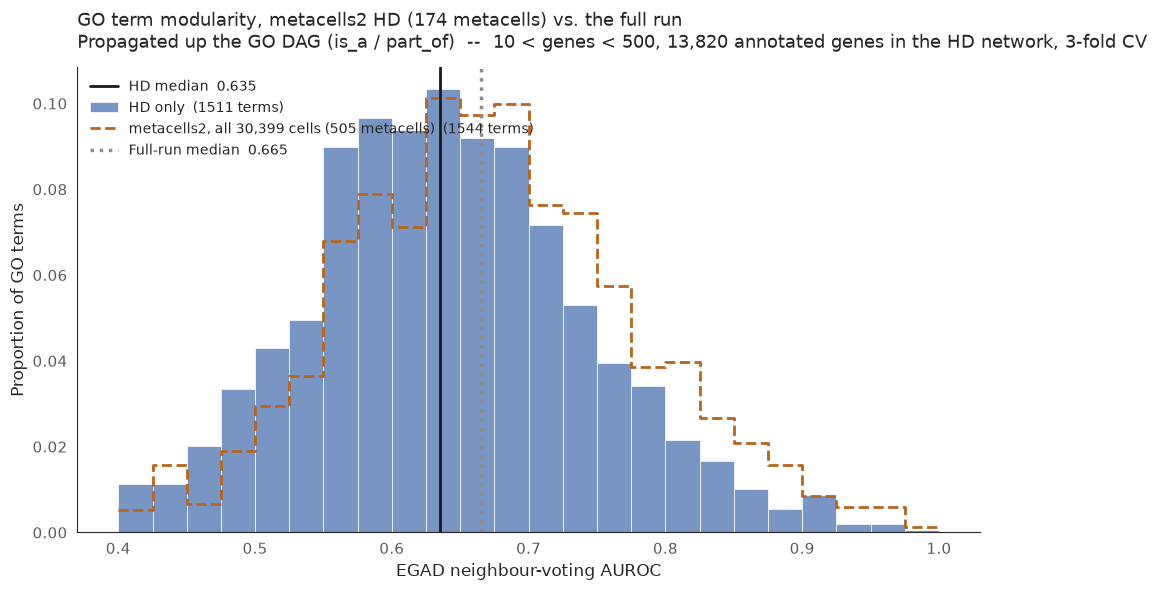

Propagated up the GO DAG (is_a / part_of)
  HD        median 0.635, 1511 terms
  full run  median 0.665, 1544 terms
  difference -0.030


In [19]:
plot_auroc_histogram(
    results_propagated,
    full_results_propagated,
    "Propagated up the GO DAG (is_a / part_of)",
)

## Step 7 — the same terms, both networks

The distributions above are over different term sets. This is the like-for-like read: only
the terms scoreable in **both** networks, paired.

In [20]:
for label, full_frame, hd_frame in [
    ("direct", full_results, results),
    ("propagated", full_results_propagated, results_propagated),
]:
    both = full_frame[["AUC", "n_genes", "term_name"]].join(
        hd_frame[["AUC", "n_genes"]], lsuffix="_full", rsuffix="_hd", how="inner"
    )
    change = both["AUC_hd"] - both["AUC_full"]
    print(
        f"{label}: {len(both)} terms scored in both networks\n"
        f"  median AUROC {both['AUC_full'].median():.3f} (full) -> "
        f"{both['AUC_hd'].median():.3f} (HD), median change {change.median():+.3f}\n"
        f"  {int((change > 0).sum())} higher in HD, {int((change < 0).sum())} higher in "
        f"the full run\n"
        f"  median genes per term {int(both['n_genes_full'].median())} -> "
        f"{int(both['n_genes_hd'].median())}\n"
    )
    if label == "direct":
        shared_direct = both.assign(AUC_change=change)

shared_direct.sort_values("AUC_change", key=abs, ascending=False).head(12)[
    ["term_name", "n_genes_full", "n_genes_hd", "AUC_full", "AUC_hd", "AUC_change"]
]

direct: 517 terms scored in both networks
  median AUROC 0.700 (full) -> 0.660 (HD), median change -0.036
  160 higher in HD, 357 higher in the full run
  median genes per term 19 -> 19

propagated: 1503 terms scored in both networks
  median AUROC 0.665 (full) -> 0.635 (HD), median change -0.029
  476 higher in HD, 1027 higher in the full run
  median genes per term 30 -> 30



,term_name,n_genes_full,n_genes_hd,AUC_full,AUC_hd,AUC_change
GO,,,,,,
GO:0034098,VCP-NPL4-UFD1 AAA ATPase complex,14,14,0.787773,0.309995,-0.477778
GO:0009395,phospholipid catabolic process,16,15,0.811926,0.397281,-0.414646
GO:0035145,exon-exon junction complex,12,13,0.742353,0.363094,-0.379258
GO:0030036,actin cytoskeleton organization,16,12,0.752385,0.401859,-0.350526
GO:0007035,vacuolar acidification,13,13,0.803076,0.457256,-0.345820
GO:0016593,Cdc73/Paf1 complex,11,11,0.792327,0.448412,-0.343915
GO:0005832,chaperonin-containing T-complex,15,15,0.894359,0.555430,-0.338929
GO:0072657,protein localization to membrane,18,14,0.837490,0.516968,-0.320522
GO:0034976,response to endoplasmic reticulum stress,16,17,0.747372,0.427449,-0.319923


In [36]:
shared_direct.loc[shared_direct["AUC_full"] > 0.5].sort_values(
    "AUC_change", ascending=False
).head(20)

,AUC_full,n_genes_full,term_name,AUC_hd,n_genes_hd,AUC_change
GO,,,,,,
GO:0072686,0.614621,14,mitotic spindle,0.831089,14,0.216468
GO:0008643,0.526636,19,carbohydrate transport,0.703383,19,0.176747
GO:0018230,0.528506,17,peptidyl-L-cysteine S-palmitoylation,0.700708,16,0.172202
GO:0098656,0.589309,11,monoatomic anion transmembrane transport,0.742774,11,0.153465
GO:0006783,0.618429,11,heme biosynthetic process,0.770647,11,0.152218
GO:0006898,0.693082,11,receptor-mediated endocytosis,0.845077,11,0.151995
GO:0010960,0.568203,11,magnesium ion homeostasis,0.719794,11,0.151591
GO:0046854,0.606577,31,phosphatidylinositol phosphate biosynthetic pr...,0.745854,28,0.139277
GO:0006612,0.551104,27,protein targeting to membrane,0.677630,27,0.126526


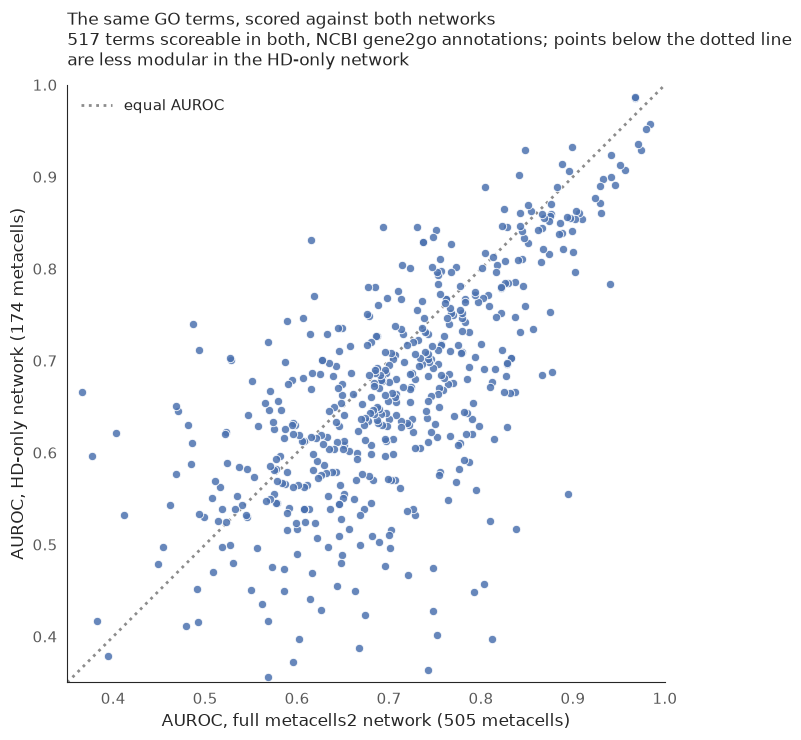

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

ax.plot(
    [0.35, 1.0],
    [0.35, 1.0],
    color="#8C8C8C",
    linestyle=":",
    linewidth=2,
    zorder=1,
    label="equal AUROC",
)
ax.scatter(
    shared_direct["AUC_full"],
    shared_direct["AUC_hd"],
    s=36,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.85,
    zorder=2,
)

ax.set_xlim(0.35, 1.0)
ax.set_ylim(0.35, 1.0)
ax.set_aspect("equal")
ax.set_xlabel("AUROC, full metacells2 network (505 metacells)", fontsize=12)
ax.set_ylabel(f"AUROC, HD-only network ({N_HD_METACELLS} metacells)", fontsize=12)
ax.set_title(
    "The same GO terms, scored against both networks\n"
    f"{len(shared_direct)} terms scoreable in both, NCBI gene2go annotations; points "
    "below the dotted line\nare less modular in the HD-only network",
    fontsize=12,
    loc="left",
    pad=14,
)
ax.legend(loc="upper left", frameon=False, fontsize=11)
ax.grid(False)
sns.despine(ax=ax)
ax.tick_params(labelsize=11, colors="#5A5A5A")
fig.tight_layout()
plt.show()

# Part 3 — co-expression conservation vs. the bulk network

Same fine-to-bulk score as
[`../Coexpression_conservation/`](../Coexpression_conservation/): for each gene, take its
top 10 partners in the bulk `soybean_prioAggNet.hdf5` network and ask where those 10 rank
in the HD network's column for that gene.

In [22]:
# The EGAD network frame is ~1.4 GB and is not needed again; the two matrices below are
# larger still, so release it before loading them.
del network

BULK_NET = os.path.join(REFERENCE_DIR, "soybean_prioAggNet.hdf5")
META_NET = NETWORK_PATH  # the HD network built in part 1
SCORES_OUT = "metacells2_HD_vs_bulk_conservation_scores.csv"
FULL_SCORES_PATH = (
    "../Coexpression_conservation/metacells2_vs_bulk_conservation_scores.csv"
)

TOP_N_PARTNERS = 10  # size of the bulk-network partner set, per the reference notebook
DOT_CHUNK_COLS = 1000  # columns per chunk in the mask-by-ranks product

In [23]:
def glyma_to_locustag(gene):
    """Glyma.01G161700.Wm82.a4.v1 -> GLYMA_01G161700v4 (the NCBI LocusTag form)."""
    core = gene.split(".Wm82")[0]  # Glyma.01G161700
    return "GLYMA_" + core.split(".", 1)[1] + "v4"


# gene_info can carry a LocusTag more than once; keep the first so the map stays 1:1.
locus_to_symbol = (
    gene_info.dropna(subset=["LocusTag", "Symbol"])
    .drop_duplicates(subset="LocusTag", keep="first")
    .set_index("LocusTag")["Symbol"]
    .to_dict()
)
print(f"LocusTag -> Symbol entries: {len(locus_to_symbol):,}")

with h5py.File(META_NET, "r") as handle:
    meta_genes = handle["genes"].asstr()[:]
with h5py.File(BULK_NET, "r") as handle:
    bulk_genes = handle["row"].asstr()[:]
    assert (handle["row"][:] == handle["col"][:]).all(), "bulk net rows != cols"

print(f"metacell network: {len(meta_genes):,} genes  e.g. {meta_genes[0]}")
print(f"bulk network:     {len(bulk_genes):,} genes  e.g. {bulk_genes[0]}")
print(f"direct name overlap: {len(set(meta_genes) & set(bulk_genes)):,}")

bulk_position = {gene: i for i, gene in enumerate(bulk_genes)}

# Walk the metacell genes and keep those that reach a gene present in the bulk network.
pairs = []  # (metacell gene, bulk gene, metacell index, bulk index)
no_locustag, no_bulk_entry = [], []
for meta_position, gene in enumerate(meta_genes):
    symbol = locus_to_symbol.get(glyma_to_locustag(gene))
    if symbol is None:
        no_locustag.append(gene)
    elif symbol not in bulk_position:
        no_bulk_entry.append(gene)
    else:
        pairs.append((gene, symbol, meta_position, bulk_position[symbol]))

mapping = pd.DataFrame(
    pairs, columns=["metacell_gene", "bulk_gene", "meta_idx", "bulk_idx"]
)
print(
    f"\nMapped {len(mapping):,} of {len(meta_genes):,} metacell genes "
    f"({len(mapping) / len(meta_genes):.1%})"
)
print(f"  no LocusTag match in gene_info: {len(no_locustag):,}")
print(f"  mapped but absent from bulk net: {len(no_bulk_entry):,}")

# Guard against many-to-one collapse, which would put duplicate rows in the network.
collisions = mapping["bulk_gene"].duplicated().sum()
if collisions:
    print(f"  dropping {collisions:,} metacell genes sharing a bulk gene")
    mapping = mapping.drop_duplicates(subset="bulk_gene", keep="first")

# h5py fancy indexing needs strictly increasing indices, so order by bulk position.
mapping = mapping.sort_values("bulk_idx").reset_index(drop=True)
n_shared = len(mapping)
meta_idx = mapping["meta_idx"].to_numpy()
bulk_idx = mapping["bulk_idx"].to_numpy()
shared_genes = mapping["metacell_gene"].to_numpy()
print(f"\nShared gene set for the comparison: {n_shared:,} genes")
mapping.head()

LocusTag -> Symbol entries: 40,814
metacell network: 21,603 genes  e.g. Glyma.01G161700.Wm82.a4.v1
bulk network:     40,825 genes  e.g. LOC100808170
direct name overlap: 0

Mapped 19,947 of 21,603 metacell genes (92.3%)
  no LocusTag match in gene_info: 1,604
  mapped but absent from bulk net: 52

Shared gene set for the comparison: 19,947 genes


,metacell_gene,bulk_gene,meta_idx,bulk_idx
0,Glyma.01G000400.Wm82.a4.v1,LOC100781438,15467,3
1,Glyma.01G000600.Wm82.a4.v1,LOC100788220,235,4
2,Glyma.01G000900.Wm82.a4.v1,LOC100779643,15443,5
3,Glyma.01G001000.Wm82.a4.v1,LOC100499919,4273,6
4,Glyma.01G001100.Wm82.a4.v1,LOC100792431,19558,7


In [24]:
def read_network_subset(path, dataset, index, chunk_rows=READ_CHUNK_ROWS):
    """Read a symmetric gene x gene subset without materialising the full matrix.

    `index` may be in any order; h5py needs strictly increasing row indices, so rows are
    fetched sorted and written straight to their destination slots.
    """
    order = np.argsort(index)
    sorted_index = index[order]
    size = len(index)
    out = np.empty((size, size), dtype=np.float32)
    with h5py.File(path, "r") as handle:
        dset = handle[dataset]
        for start in range(0, size, chunk_rows):
            stop = min(start + chunk_rows, size)
            block = dset[sorted_index[start:stop], :]
            out[order[start:stop]] = block[:, index].astype(np.float32)
    return out


print(
    f"Reading bulk network subset ({n_shared:,} x {n_shared:,}, "
    f"~{n_shared ** 2 * 4 / 1e9:.2f} GB) ..."
)
bulk_sub = read_network_subset(BULK_NET, "agg", bulk_idx)
print(
    f"  values span {bulk_sub.min():.6f} to {bulk_sub.max():.6f}, "
    f"median {np.median(bulk_sub):.4f}"
)

# The reference notebook zeroes self-edges with .replace(1, 0), which also clobbers any
# off-diagonal edge that happens to sit at exactly 1.0. Zero the diagonal explicitly
# instead, and report what the blunt version would have caught.
off_diagonal_ones = int((bulk_sub == 1.0).sum()) - n_shared
print(
    f"  off-diagonal edges at exactly 1.0: {off_diagonal_ones:,} "
    f"(kept here, dropped by .replace(1, 0))"
)
np.fill_diagonal(bulk_sub, 0.0)

Reading bulk network subset (19,947 x 19,947, ~1.59 GB) ...
  values span 0.000000 to 1.000000, median 0.7815
  off-diagonal edges at exactly 1.0: 0 (kept here, dropped by .replace(1, 0))


In [25]:
# Per column, the row indices of the TOP_N_PARTNERS largest edges.
top_partners = np.argpartition(-bulk_sub, TOP_N_PARTNERS, axis=0)[:TOP_N_PARTNERS, :]
del bulk_sub  # mask is all that is needed from here on

mask = sp.csr_matrix(
    (
        np.ones(n_shared * TOP_N_PARTNERS, dtype=np.float32),
        (np.repeat(np.arange(n_shared), TOP_N_PARTNERS), top_partners.T.ravel()),
    ),
    shape=(n_shared, n_shared),
)
print(f"Top-{TOP_N_PARTNERS} mask: {mask.shape[0]:,} genes x {mask.nnz:,} edges")
print(
    f"  edges per gene: min={mask.getnnz(axis=1).min()}, "
    f"max={mask.getnnz(axis=1).max()}"
)

Top-10 mask: 19,947 genes x 199,470 edges
  edges per gene: min=10, max=10


In [26]:
print(f"Reading metacell network subset ({n_shared:,} x {n_shared:,}) ...")
meta_sub = read_network_subset(META_NET, "network", meta_idx)

# The reference notebook clips its network at 0 because it feeds in raw Spearman values.
# Ours is already rank standardised onto (0, 1], so the clip is a no-op -- and since the
# score depends only on within-column ranks, the rank standardisation itself cannot
# change the result either way.
negative_edges = int((meta_sub < 0).sum())
print(f"  negative edges needing a clip: {negative_edges:,}")
np.clip(meta_sub, 0, None, out=meta_sub)
np.fill_diagonal(meta_sub, 0.0)

# Rank down each column, in place and in chunks to avoid a float64 copy of the matrix.
print("Ranking each column of the metacell network ...")
for start in range(0, n_shared, DOT_CHUNK_COLS):
    stop = min(start + DOT_CHUNK_COLS, n_shared)
    meta_sub[:, start:stop] = sci.rankdata(
        meta_sub[:, start:stop], method="average", axis=0
    ).astype(np.float32)
print(f"  ranks span {meta_sub.min():.0f} to {meta_sub.max():.0f}")

Reading metacell network subset (19,947 x 19,947) ...
  negative edges needing a clip: 0
Ranking each column of the metacell network ...
  ranks span 1 to 19947


In [27]:
# Lowest attainable rank sum: rank 1 belongs to the zeroed self-edge.
MINIMUM_RANK_SUM = sum(range(2, TOP_N_PARTNERS + 2))
print(f"Minimum attainable rank sum: {MINIMUM_RANK_SUM}")

diagonal = np.empty(n_shared, dtype=np.float64)
global_max, global_min = -np.inf, np.inf

print("Computing mask . ranks in column chunks ...")
for start in range(0, n_shared, DOT_CHUNK_COLS):
    stop = min(start + DOT_CHUNK_COLS, n_shared)
    block = mask.dot(meta_sub[:, start:stop])
    global_max = max(global_max, float(block.max()))
    global_min = min(global_min, float(block.min()))
    diagonal[start:stop] = block[np.arange(start, stop), np.arange(stop - start)]

print(f"  full product spans {global_min:,.0f} to {global_max:,.0f}")

score_range = global_max - global_min
conservation_scores = pd.Series(
    (diagonal - MINIMUM_RANK_SUM) / score_range,
    index=shared_genes,
    name="conservation_score",
)

median_score = float(conservation_scores.median())
print(f"\nMedian conservation score: {median_score:.4f}")
print(
    f"  mean {conservation_scores.mean():.4f}, "
    f"IQR {conservation_scores.quantile(0.25):.4f}-"
    f"{conservation_scores.quantile(0.75):.4f}"
)
print(f"  range {conservation_scores.min():.4f} to {conservation_scores.max():.4f}")
print(f"\nArabidopsis fine-to-bulk reference median: 0.8626")
conservation_scores.head()

Minimum attainable rank sum: 65
Computing mask . ranks in column chunks ...
  full product spans 151 to 199,379

Median conservation score: 0.6681
  mean 0.6715, IQR 0.5581-0.7893
  range 0.0480 to 1.0002

Arabidopsis fine-to-bulk reference median: 0.8626


Glyma.01G000400.Wm82.a4.v1    0.495417
Glyma.01G000600.Wm82.a4.v1    0.436555
Glyma.01G000900.Wm82.a4.v1    0.520931
Glyma.01G001000.Wm82.a4.v1    0.915047
Glyma.01G001100.Wm82.a4.v1    0.771593
Name: conservation_score, dtype: float64

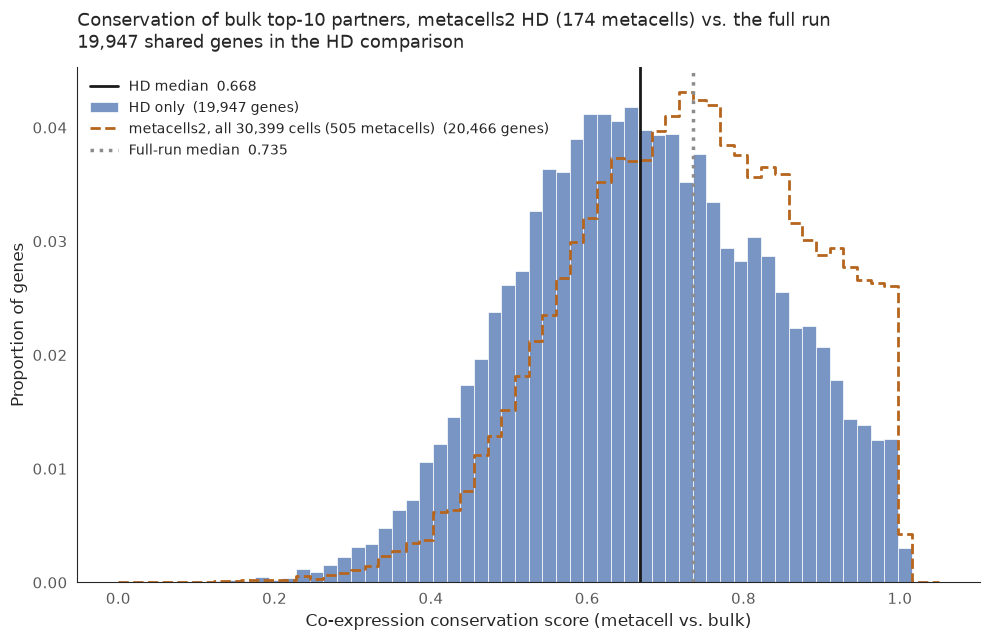

HD        median 0.6681, 19,947 genes
full run  median 0.7348, 20,466 genes
difference -0.0667

19,286 genes scored in both:
  median 0.7320 (full) -> 0.6702 (HD)
  median per-gene change -0.0460
  Spearman between the two: 0.734


In [28]:
full_scores = pd.read_csv(FULL_SCORES_PATH, index_col=0)["conservation_score"]
full_median = float(full_scores.median())

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6.5))

sns.histplot(
    conservation_scores,
    bins=60,
    binrange=(0, 1.05),
    stat="proportion",
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
    label=f"HD only  ({len(conservation_scores):,} genes)",
)
sns.histplot(
    full_scores,
    bins=60,
    binrange=(0, 1.05),
    stat="proportion",
    element="step",
    fill=False,
    color="#B5651D",
    linewidth=2,
    linestyle="--",
    ax=ax,
    label=f"{FULL_LABEL}  ({len(full_scores):,} genes)",
)

ax.axvline(
    median_score,
    color="#1A1A1A",
    linestyle="-",
    linewidth=2,
    label=f"HD median  {median_score:.3f}",
)
ax.axvline(
    full_median,
    color="#8C8C8C",
    linestyle=":",
    linewidth=2.5,
    label=f"Full-run median  {full_median:.3f}",
)

ax.set_xlabel("Co-expression conservation score (metacell vs. bulk)", fontsize=12)
ax.set_ylabel("Proportion of genes", fontsize=12)
ax.set_title(
    f"Conservation of bulk top-{TOP_N_PARTNERS} partners, {NETWORK_LABEL} vs. the full "
    f"run\n{n_shared:,} shared genes in the HD comparison",
    fontsize=13,
    loc="left",
    pad=14,
)
# seaborn appends the bar patch last; lead with the HD series, which is the subject.
_handles, _labels = ax.get_legend_handles_labels()
_order = sorted(range(len(_labels)), key=lambda i: not _labels[i].startswith("HD"))
ax.legend(
    [_handles[i] for i in _order],
    [_labels[i] for i in _order],
    loc="upper left",
    frameon=False,
    fontsize=10,
)
ax.grid(False)
sns.despine(ax=ax)
ax.tick_params(labelsize=11, colors="#5A5A5A")
fig.tight_layout()
plt.show()

print(f"HD        median {median_score:.4f}, {len(conservation_scores):,} genes")
print(f"full run  median {full_median:.4f}, {len(full_scores):,} genes")
print(f"difference {median_score - full_median:+.4f}")

paired = pd.concat(
    [conservation_scores.rename("hd"), full_scores.rename("full")], axis=1, join="inner"
)
print(f"\n{len(paired):,} genes scored in both:")
print(
    f"  median {paired['full'].median():.4f} (full) -> {paired['hd'].median():.4f} (HD)"
)
print(f"  median per-gene change {(paired['hd'] - paired['full']).median():+.4f}")
print(f"  Spearman between the two: {paired.corr(method='spearman').iloc[0, 1]:.3f}")

In [29]:
conservation_scores.sort_values(ascending=False).to_csv(SCORES_OUT, header=True)
print(f"Saved {len(conservation_scores):,} per-gene scores to {SCORES_OUT}")

print("\nMost conserved genes:")
print(conservation_scores.nlargest(10).round(4).to_string())
print("\nLeast conserved genes:")
print(conservation_scores.nsmallest(10).round(4).to_string())

Saved 19,947 per-gene scores to metacells2_HD_vs_bulk_conservation_scores.csv

Most conserved genes:
Glyma.07G185500.Wm82.a4.v1    1.0002
Glyma.14G099900.Wm82.a4.v1    1.0002
Glyma.15G221300.Wm82.a4.v1    1.0000
Glyma.19G211700.Wm82.a4.v1    0.9999
Glyma.18G103500.Wm82.a4.v1    0.9998
Glyma.02G104600.Wm82.a4.v1    0.9997
Glyma.18G106300.Wm82.a4.v1    0.9995
Glyma.09G155500.Wm82.a4.v1    0.9994
Glyma.10G177200.Wm82.a4.v1    0.9994
Glyma.15G186400.Wm82.a4.v1    0.9994

Least conserved genes:
Glyma.03G014300.Wm82.a4.v1    0.0480
Glyma.12G185600.Wm82.a4.v1    0.1040
Glyma.13G174300.Wm82.a4.v1    0.1228
Glyma.09G071100.Wm82.a4.v1    0.1262
Glyma.09G087200.Wm82.a4.v1    0.1390
Glyma.02G081000.Wm82.a4.v1    0.1429
Glyma.08G047800.Wm82.a4.v1    0.1494
Glyma.03G256500.Wm82.a4.v1    0.1544
Glyma.17G092400.Wm82.a4.v1    0.1570
Glyma.19G222500.Wm82.a4.v1    0.1621
